# Project Milestone Two: Modeling and Feature Engineering

### Due: Midnight on August 3 (with 2-hour grace period) and worth 50 points

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
# Add as many cells as you need
df = df = pd.read_csv('cleaned.csv') #replace the path with yours
print(df.columns)
print(df.shape)
X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

Index(['airconditioningtypeid', 'basementsqft', 'bathroomcnt', 'bedroomcnt',
       'buildingqualitytypeid', 'calculatedbathnbr',
       'calculatedfinishedsquarefeet', 'fips', 'fireplacecnt', 'fullbathcnt',
       'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'poolsizesum', 'pooltypeid2', 'pooltypeid7',
       'propertylandusetypeid', 'rawcensustractandblock', 'regionidcounty',
       'regionidzip', 'roomcnt', 'threequarterbathnbr', 'unitcnt',
       'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt',
       'numberofstories', 'taxdelinquencyflag', 'taxvaluedollarcnt',
       'propertycountylandusecode_encoded', 'propertyzoningdesc_encoded'],
      dtype='object')
(72392, 36)


### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [3]:
# Add as many cells as you need
from sklearn.metrics import mean_absolute_error

start = time.time()

base_gbr_model = GradientBoostingRegressor(random_state=random_state)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

cv_scores = -cross_val_score(
    base_gbr_model, X_train_scaled, y_train,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
print(f"Baseline Mean CV MAE: {cv_scores.mean():.2f}")
print(f"Baseline STD CV MAE: {cv_scores.std():.2f}")

base_gbr_model.fit(X_train_scaled, y_train)
y_pred_train = base_gbr_model.predict(X_train_scaled)
train_mae = mean_absolute_error(y_train, y_pred_train)
print(f"Baseline Train MAE: {train_mae:.2f}")

end = time.time()
print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

Baseline Mean CV MAE: 137948.22
Baseline STD CV MAE: 1068.54
Baseline Train MAE: 136713.08
Execution Time: 00:00:31


In [4]:
#Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(random_state=random_state)

cv= RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

cv_scores = -cross_val_score(decision_tree_model, X_train_scaled, y_train, scoring= 'neg_mean_absolute_error', cv=cv, n_jobs= -1)

print(f'Decision Tree Baseline Mean CV MAE = {cv_scores.mean():.2f}')
print(f'Decision Tree Baseline STD CV MAE = {cv_scores.std():.2f}')

#Fit training MAE
decision_tree_model.fit(X_train_scaled, y_train)
y_pred = decision_tree_model.predict(X_train_scaled)

dt_train_mae = mean_absolute_error(y_train, y_pred)

print(f'Decision Tree Baseline Train MAE = {dt_train_mae:.2f}')

Decision Tree Baseline Mean CV MAE = 174731.68
Decision Tree Baseline STD CV MAE = 1218.34
Decision Tree Baseline Train MAE = 2484.98


In [5]:
# Add as many cells as you need
from sklearn.metrics import mean_absolute_error

rf_model = RandomForestRegressor(random_state=random_state)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
cv_scores = -cross_val_score(rf_model, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=8)

print(f'Random Forest Baseline Mean CV MAE = {cv_scores.mean():.2f}')
print(f'Random Forest Baseline STD CV MAE = {cv_scores.std():.2f}')

#Fit training MAE
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_train_scaled)

rf_train_mae = mean_absolute_error(y_train, y_pred)

print(f'Random Forest Baseline Train MAE = {rf_train_mae:.2f}')


Random Forest Baseline Mean CV MAE = 134894.31
Random Forest Baseline STD CV MAE = 941.77
Random Forest Baseline Train MAE = 50810.35


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

The model GradientboostingRegressor got baseline mean of cv MAE: 137987.07, train MAE: 136634.72, STD of cv MAE: 1095.47. STD is a little bit high, and the train MAE is slightly lower than the mean of cv MAE, it could be slightly underfitting.

The Decision Tree Regression Model has a baseline mean CV MAE of 174817.23, which suggests that there is overfitting and is performing poorly on the unseen data. Also it has a standard deviation (STD) CV MAE of 1357.49, which is low and indicates consistency across the splits. The Train MAE of the model is 2484.98 so it is very low. This means the decision tree regression model fits the training data closely. 

The Random Forest Regression model achieved a baseline mean CV MAE of 134,907.02, a very low train MAE of 50,854.35, and a CV MAE standard deviation of 936.88, indicating high training performance but a strong risk of overfitting.

1. Which model performed best overall?
The Random Forest model had the lowest mean CV MAE (134,907.02), indicating the best performance on unseen data overall.

2. Which was most stable (lowest std)?
The Random Forest model was also the most stable, with the lowest CV MAE standard deviation (936.88), suggesting consistent performance across folds.

3. Any signs of overfitting or underfitting?
Yes, Random Forest shows signs of overfitting. Its train MAE (50,854.35) is much lower than the CV MAE (134,907.02), indicating the model fits the training data too well but doesn’t generalize as effectively.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [6]:
# Add as many cells as you need
X_train['log_sqft'] = np.log1p(X_train['calculatedfinishedsquarefeet'])
X_train['bath_product'] = X_train['calculatedbathnbr'] * X_train['bathroomcnt']
X_train['age_squared'] = (2025 - X_train['yearbuilt'])**2

X_train_scaled = scaler.fit_transform(X_train)

In [7]:
start = time.time()

base_gbr_model = GradientBoostingRegressor(random_state=random_state)

cv_scores = -cross_val_score(
    base_gbr_model, X_train_scaled, y_train,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
print(f"Baseline Mean CV MAE (w/ New Features): {cv_scores.mean():.2f}")
print(f"Baseline STD CV MAE (w/ New Features): {cv_scores.std():.2f}")

base_gbr_model.fit(X_train_scaled, y_train)
y_pred_train = base_gbr_model.predict(X_train_scaled)
train_mae = mean_absolute_error(y_train, y_pred_train)
print(f"Baseline Train MAE (w/ New Features): {train_mae:.2f}")

end = time.time()
print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

Baseline Mean CV MAE (w/ New Features): 137967.00
Baseline STD CV MAE (w/ New Features): 1043.28
Baseline Train MAE (w/ New Features): 136788.84
Execution Time: 00:00:35


In [8]:
#Decision Tree Regression 
decision_tree_model = DecisionTreeRegressor(random_state= random_state)
cv = RepeatedKFold(n_splits= 5, n_repeats= 5, random_state= random_state)

cv_scores = -cross_val_score(decision_tree_model, X_train_scaled, y_train, scoring= 'neg_mean_absolute_error', cv= cv, n_jobs= -1)

print(f'Decision Tree Baseline Mean CV MAE with 3 New Features = {cv_scores.mean():.2f}')
print(f'Decision Tree Baseline STD CV MAE with 3 New Features = {cv_scores.std():.2f}')

decision_tree_model.fit(X_train_scaled, y_train)
y_pred = decision_tree_model.predict(X_train_scaled)
dt_train_mae = mean_absolute_error(y_train, y_pred)

print(f'Decision Tree Baseline Train MAE with 3 New Features = {dt_train_mae:.2f}')

Decision Tree Baseline Mean CV MAE with 3 New Features = 174694.70
Decision Tree Baseline STD CV MAE with 3 New Features = 1311.66
Decision Tree Baseline Train MAE with 3 New Features = 2484.98


In [9]:
rf_model = RandomForestRegressor(random_state=random_state)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
cv_scores = -cross_val_score(rf_model, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=8)

print(f'Random Forest Baseline Mean CV MAE with 3 New Features = {cv_scores.mean():.2f}')
print(f'Random Forest Baseline STD CV MAE with 3 New Features = {cv_scores.std():.2f}')

rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_train_scaled)
rf_train_mae = mean_absolute_error(y_train, y_pred)

print(f'Random Forest Baseline Train MAE with 3 New Features = {rf_train_mae:.2f}')

Random Forest Baseline Mean CV MAE with 3 New Features = 134921.17
Random Forest Baseline STD CV MAE with 3 New Features = 945.98
Random Forest Baseline Train MAE with 3 New Features = 50827.24


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




For the Model GradientBoostingRegressor, there is no big difference, could ignore it. Can't really tell which new features is helpful and in which models. I do have a hypothesis that log_sqft helps the results because in Milestone1, log_sqft got the highest correlation score and F-score among all the new features.

After performing feature engineering and using the Decision Tree Regression model, the Mean CV MAE score is 174731.22, which indicates a slight improvement when compared to the score of 174817.23 in Part 1. Here, the STD CV MAE is 1225.54 and in Part 1 it was 1357.49. This suggests an even better consistency rate across the splits. However, the Train MAE is 2484.98, which is the same as in Part 1, meaning there is still overfitting. Overall, the three features slightly improved the model, with log_sqft most likely helping by normalizing the distribution. A hypothesis of why age_squared did not help the model is because squaring the house age values made them even larger, leading to a disproportionate range, where the feature values are skewed.

For the Random Forest Regressor, the addition of the new features slightly worsened the model’s performance. The baseline mean CV MAE increased from 134,907.02 to 134,946.27, and the standard deviation of CV MAE also increased from 936.88 to 967.45, indicating a small decrease in consistency. The train MAE remained almost the same, changing from 50,854.35 to 50,851.56, which shows the model still fits the training data closely.

This suggests that the new features did not improve the Random Forest model and may have introduced a bit of noise. Since the training error is much lower than the cross-validation error, there are still signs of overfitting.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [10]:
def forward_feature_selection(X, y, model,
                                      scoring='neg_mean_absolute_error',
                                      cv=5,
                                      tol=None,               # None = no delta cutoff
                                                              # use 0.0 for "no further improvements"
                                                              # and 1e-4 for "point of diminishing returns"
                                      max_features=None,      # None = use all features
                                      n_jobs = -1,
                                      verbose = True
                                     ):
    selected_features = []
    remaining_features = list(X.columns)
    best_scores = []
    previous_score = float('inf')

    # Track the best subset and its score
    best_forward_features = None
    best_score = float('inf')

    while remaining_features:
        scores = {}
        for feature in remaining_features:
            current_features = selected_features + [feature]
            # Compute the CV score
            cv_score = -cross_val_score(model, X[current_features], y,
                                        scoring=scoring, cv=cv,n_jobs=n_jobs,
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key=scores.get)
        current_score = scores[best_feature]

        # Check if the improvement is significant
        if verbose and tol is not None and previous_score - current_score < tol:
            print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"Features: {selected_features}, CV Score (MAE): {current_score:.4f}")

        # Update the best subset if the current score is the best so far
        if current_score < best_score:
            best_score = current_score
            best_forward_features = selected_features.copy()

        # Check if max_features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

    return selected_features, best_scores, best_forward_features, best_score

In [11]:
def backward_feature_selection(X, y, model,
                               scoring='neg_mean_absolute_error',
                               cv=5,
                               tol=None,               # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"
                               max_features=None,      # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs=-1,
                               verbose=True
                              ):

    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y,
                                scoring=scoring, cv=cv,
                                n_jobs=n_jobs          ).mean()

    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)

    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)

    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)

    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (MAE): {np.around(initial_score, 4)}\n')

    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features

    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')

        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None

        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(new_score, 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set

        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break

        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()

        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)

        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (MAE) {np.around(lowest_score, 4)}\n')
        round_num += 1

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score              # Best (lowest) CV score
    )

In [12]:
#Defined gbr model
gbr = GradientBoostingRegressor(random_state=random_state)
X_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

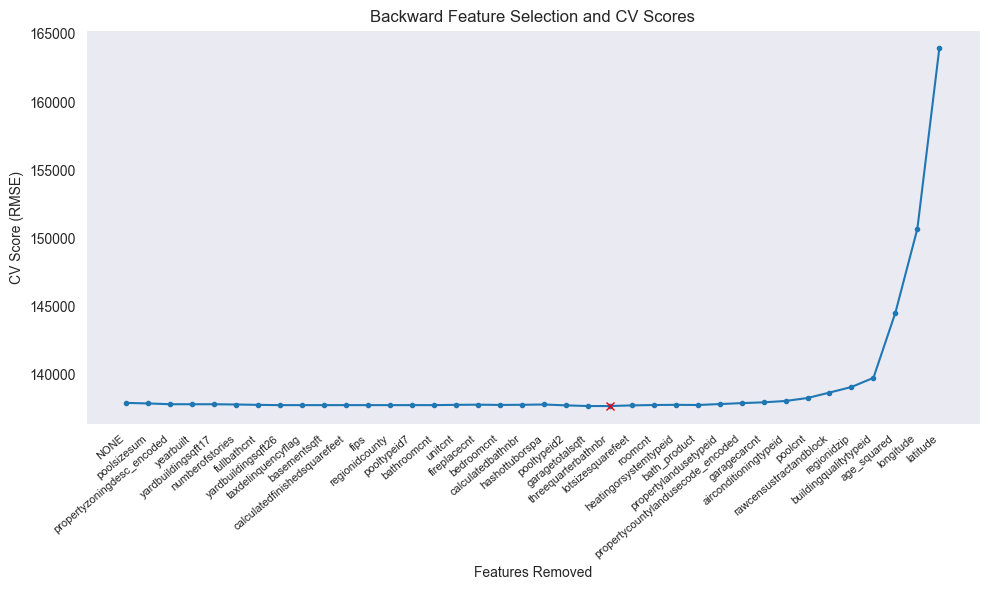

Best feature set: ['airconditioningtypeid', 'buildingqualitytypeid', 'garagecarcnt', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidzip', 'roomcnt', 'propertycountylandusecode_encoded', 'log_sqft', 'bath_product', 'age_squared']
CV score (MSE): 137718.5122


In [13]:
#Using backward_feature_selection for gbr model
selected_features, best_scores, best_feature_set, best_score = (
        backward_feature_selection(X_scaled_df, y_train, gbr, verbose=False)
)

plt.figure(figsize=(10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker='x', color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=40, ha='right', fontsize=8)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print minimum cv score

print("Best feature set:", best_feature_set)
print("CV score (MSE):",np.around(best_score,4))

In [14]:
#MAE with best features
start = time.time()
X_best = X_scaled_df[best_feature_set].values

cv_scores = -cross_val_score(
    gbr,
    X_best,
    y_train,
    scoring='neg_mean_absolute_error',
    cv=RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state),
    n_jobs=-1
)

print(f"Mean CV MAE: {cv_scores.mean():.2f}")
print(f"STD CV MAE: {cv_scores.std():.2f}")

end = time.time()
print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

Mean CV MAE: 137850.85
STD CV MAE: 1099.86
Execution Time: 00:00:14


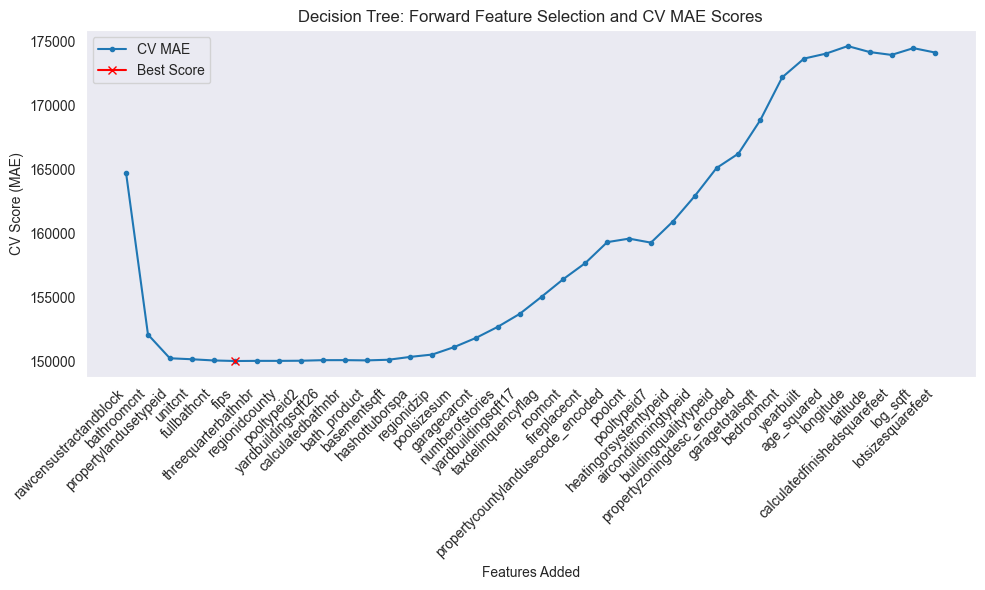

Decision Tree: Best Feature Set = ['rawcensustractandblock', 'bathroomcnt', 'propertylandusetypeid', 'unitcnt', 'fullbathcnt', 'fips']
Decision Tree: Best CV MAE Score = 150041.37


In [15]:
#Decision Tree Regression - Forward Feature Selection

scaled_df = pd.DataFrame(X_train_scaled, columns= X_train.columns)

#Defining model and cv
decision_tree_model = DecisionTreeRegressor(random_state= random_state)
cv = RepeatedKFold(n_splits= 5, n_repeats= 5, random_state= random_state)

#Forward feature selection
dt_forward_selected_features, dt_forward_scores, dt_forward_best_set, dt_forward_best_score = (
    forward_feature_selection(scaled_df, y_train, decision_tree_model, verbose= False)
)

#Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(dt_forward_scores) + 1), dt_forward_scores, marker='.', label= 'CV MAE')
best_index = np.argmin(dt_forward_scores)
plt.plot([best_index + 1], dt_forward_scores[best_index], marker='x', color='red', label= 'Best Score')
plt.xticks(range(1, len(dt_forward_selected_features) + 1), dt_forward_selected_features, rotation=45, ha='right')
plt.title('Decision Tree: Forward Feature Selection and CV MAE Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (MAE)')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

print(f"Decision Tree: Best Feature Set = {dt_forward_best_set}")
print(f"Decision Tree: Best CV MAE Score = {dt_forward_best_score:.2f}")

In [16]:
X_best_forward = scaled_df[dt_forward_best_set]

cv_scores = -cross_val_score(
    decision_tree_model,
    X_best_forward,
    y_train,
    scoring='neg_mean_absolute_error',
    cv= cv,
    n_jobs=-1
)

print(f'Final Mean CV MAE (Forward Feature Selection) = {cv_scores.mean():.2f}')
print(f'Final STD CV MAE (Forward Feature Selection) = {cv_scores.std():.2f}')

Final Mean CV MAE (Forward Feature Selection) = 150273.15
Final STD CV MAE (Forward Feature Selection) = 1120.08


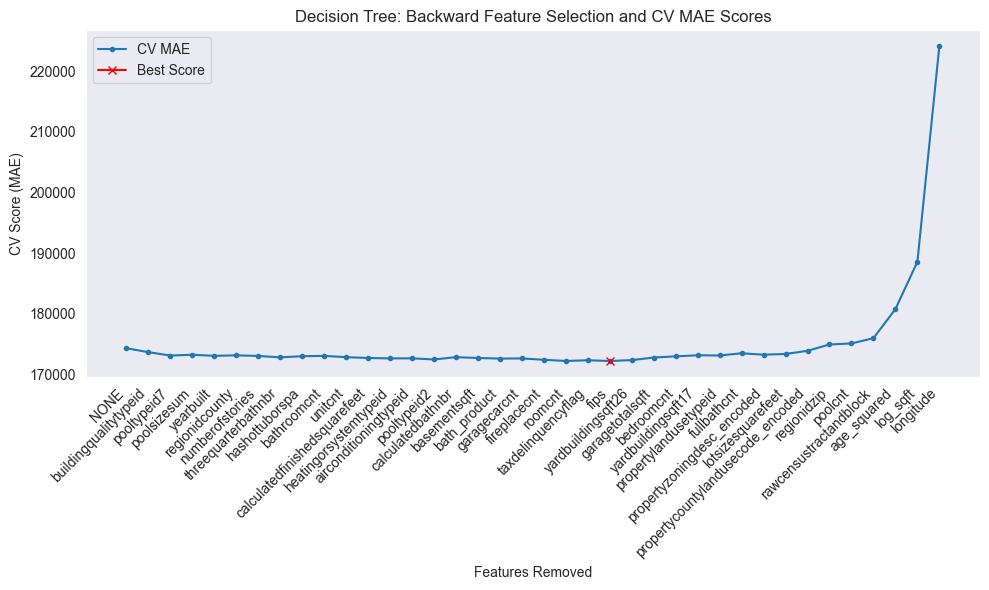

Decision Tree: Best Feature Set = ['bedroomcnt', 'fullbathcnt', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidzip', 'yardbuildingsqft17', 'yardbuildingsqft26', 'propertycountylandusecode_encoded', 'propertyzoningdesc_encoded', 'log_sqft', 'age_squared']
Decision Tree: Best CV MAE Score = 172216.51


In [17]:
#Decision Tree Regression - Backward Feature Selection

dt_backward_selected_features, dt_backward_scores, dt_backward_best_set, dt_backward_best_score = (
    backward_feature_selection(scaled_df, y_train, decision_tree_model, verbose= False)
)

#Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(dt_backward_scores) + 1), dt_backward_scores, marker='.', label= 'CV MAE')
best_index = np.argmin(dt_backward_scores)
plt.plot([best_index + 1], dt_backward_scores[best_index], marker='x', color='red', label= 'Best Score')
plt.xticks(range(1, len(dt_backward_selected_features) + 1), dt_backward_selected_features, rotation=45, ha='right')
plt.title('Decision Tree: Backward Feature Selection and CV MAE Scores')
plt.xlabel('Features Removed')
plt.ylabel('CV Score (MAE)')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

print(f"Decision Tree: Best Feature Set = {dt_backward_best_set}")
print(f"Decision Tree: Best CV MAE Score = {dt_backward_best_score:.2f}")


In [18]:
X_best_backward = scaled_df[dt_backward_best_set]

cv_scores = -cross_val_score(
    decision_tree_model,
    X_best_backward,
    y_train,
    scoring='neg_mean_absolute_error',
    cv= cv,
    n_jobs=-1
)

print(f'Final Mean CV MAE (Backward Feature Selection) = {cv_scores.mean():.2f}')
print(f'Final STD CV MAE (Backward Feature Selection) =  {cv_scores.std():.2f}')

Final Mean CV MAE (Backward Feature Selection) = 174289.21
Final STD CV MAE (Backward Feature Selection) =  1297.02


Random Forest

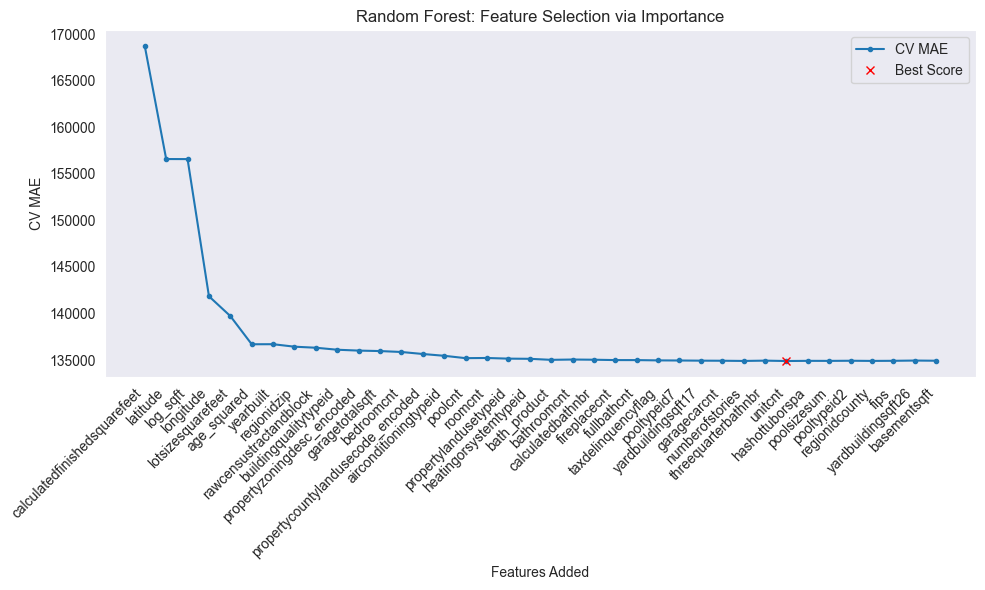

Best features set: ['calculatedfinishedsquarefeet', 'latitude', 'log_sqft', 'longitude', 'lotsizesquarefeet', 'age_squared', 'yearbuilt', 'regionidzip', 'rawcensustractandblock', 'buildingqualitytypeid', 'propertyzoningdesc_encoded', 'garagetotalsqft', 'bedroomcnt', 'propertycountylandusecode_encoded', 'airconditioningtypeid', 'poolcnt', 'roomcnt', 'propertylandusetypeid', 'heatingorsystemtypeid', 'bath_product', 'bathroomcnt', 'calculatedbathnbr', 'fireplacecnt', 'fullbathcnt', 'taxdelinquencyflag', 'pooltypeid7', 'yardbuildingsqft17', 'garagecarcnt', 'numberofstories', 'threequarterbathnbr', 'unitcnt']
Best MAE (CV): 134905.94


In [19]:
rf_model = RandomForestRegressor(random_state=random_state)
rf_model.fit(scaled_df, y_train)

# I
importances = pd.Series(rf_model.feature_importances_, index=scaled_df.columns)
importances = importances.sort_values(ascending=False)
ranked_features = importances.index.tolist()

# 
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=random_state)
scores = []
feature_sets = []

for i in range(1, len(ranked_features) + 1):
    top_feats = ranked_features[:i]
    score = -cross_val_score(rf_model, scaled_df[top_feats], y_train,
                             scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1).mean()
    scores.append(score)
    feature_sets.append(top_feats)

# Melhor conjunto
best_idx = np.argmin(scores)
best_features = feature_sets[best_idx]
best_score = scores[best_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(scores)+1), scores, marker='.', label='CV MAE')
plt.plot([best_idx+1], [best_score], 'rx', label='Best Score')
plt.xticks(range(1, len(scores)+1), ranked_features, rotation=45, ha='right')
plt.xlabel('Features Added')
plt.ylabel('CV MAE')
plt.title('Random Forest: Feature Selection via Importance')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Print resultados
print("Best features set:", best_features)
print(f"Best MAE (CV): {best_score:.2f}")

In [20]:
X_best_importances = scaled_df[best_features]

cv_scores = -cross_val_score(
    rf_model,
    X_best_importances,
    y_train,
    scoring='neg_mean_absolute_error',
    cv= cv,
    n_jobs=-1
)

print(f'Final Mean CV MAE (feature importance from tree-based models) = {cv_scores.mean():.2f}')
print(f'Final STD CV MAE (feature importance from tree-based models) =  {cv_scores.std():.2f}')

Final Mean CV MAE (feature importance from tree-based models) = 134905.94
Final STD CV MAE (feature importance from tree-based models) =  1083.23


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


For the GBR model, performance did improve after reducing the number of features. All three new features are consistently across models. Three new features are all in the best feature set for GBR model, at least they are important for the GBR model.

For the Decision Tree Regression model, after performing both forward and backward feature selection, we can see that the forward feature selection performed better with a Mean CV MAE score of 152257.50 compared to a score of 174480.15 for backward feature selection. This suggests that adding the most useful and informative features led to a overall better feature set and improved the performance of the model. It also reduced overfitting. Some of the newly engineered features were selected, but only in the backward feature selection. log_sqrt and bath_product were the ones that were selected. This suggests that they may add some value when used with other features. 

For the Random Forest model, all 3 new features were selected in the best feature set and perfomance improved a bit after reducing the number of features.

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [31]:
# Add as many cells as you need
# GradientBoostingRegressor
start = time.time()

gbr_model = GradientBoostingRegressor(random_state=random_state, learning_rate = 0.1, n_iter_no_change=10, validation_fraction=0.2, tol=1e-7)

param_dist = {
    'n_estimators'      : list(range(123, 126, 1)),
    'max_depth'         : [5],
    'max_features'      : [6],
    'min_samples_split' : [7],
    'min_samples_leaf'  : [8],
}

search = GridSearchCV(
    estimator=gbr_model,
    param_grid=param_dist,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

search.fit(X_best, y_train)

results = pd.DataFrame(search.cv_results_)

results = results[[
    'param_n_estimators',
    'param_min_samples_leaf',
    'param_max_features',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'std_train_score',
    'rank_test_score'
]]

results['mean_test_score'] = -results['mean_test_score']
results['mean_train_score'] = -results['mean_train_score']

results = results.sort_values(by='rank_test_score')

renamed_results = results.rename(
    columns={
        'param_n_estimators': 'n_estimators',
        'param_min_samples_leaf': 'min_samples_leaf',
        'param_max_features': 'max_samples',
        'mean_test_score': 'mean_cv_score',
        'std_test_score': 'std_cv_score',
        'mean_train_score': 'mean_train_score',
        'std_train_score': 'std_train_score'
    }
).drop(columns=['rank_test_score'])

print(f"\nBest Parameters: {search.best_params_}")
print(f"Best CV MAE: {-search.best_score_:.4f}")

best_gbr = search.best_estimator_
scores = -cross_val_score(
    best_gbr,
    X_best, y_train,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1
)
print(f"\nMean of CV MAE: {scores.mean():.4f}")
print(f"Std of CV MAE: {scores.std():.4f}")

end = time.time()
print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

Fitting 25 folds for each of 3 candidates, totalling 75 fits

Best Parameters: {'max_depth': 5, 'max_features': 6, 'min_samples_leaf': 8, 'min_samples_split': 7, 'n_estimators': 125}
Best CV MAE: 134438.9320

Mean of CV MAE: 134438.9320
Std of CV MAE: 971.5996
Execution Time: 00:00:35


In [22]:
#Decision Tree Regression
X_best_forward = scaled_df[dt_forward_best_set]

decision_tree_model = DecisionTreeRegressor(random_state= random_state)
cv = RepeatedKFold(n_splits= 5, n_repeats= 5, random_state= random_state)

param_dist = {
    'max_depth': [3, 5, 7, 9, 12],        
    'min_samples_split': [2, 5, 10, 15],  
    'min_samples_leaf': [1, 2, 4, 6],     
    'max_features': ['sqrt', 'log2', None]         
}

search = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=param_dist,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

search.fit(X_best_forward, y_train)

print(f"Best Parameters: {search.best_params_}")
print(f"Best CV MAE: {-search.best_score_:.2f}")

best_decision_tree = search.best_estimator_

final_cv_scores = -cross_val_score(
    best_decision_tree, X_best_forward, y_train,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1
)

print(f"Mean CV MAE: {final_cv_scores.mean():.2f}")
print(f"STD CV MAE: {final_cv_scores.std():.2f}")

Fitting 25 folds for each of 240 candidates, totalling 6000 fits
Best Parameters: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 15}
Best CV MAE: 147180.09
Mean CV MAE: 147180.09
STD CV MAE: 971.56


In [23]:
#Decision Tree Regression

#Further Tuning
X_best_forward = scaled_df[dt_forward_best_set]

decision_tree_model = DecisionTreeRegressor(random_state= random_state)
cv = RepeatedKFold(n_splits= 5, n_repeats= 5, random_state= random_state)

param_dist = {
    'max_depth': [9, 12, 15, 18],        
    'min_samples_split': [10, 15, 20],  
    'min_samples_leaf': [4, 6, 8],     
    'max_features': ['sqrt', 'log2', None]         
}

search = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=param_dist,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

search.fit(X_best_forward, y_train)

print(f"Best Parameters: {search.best_params_}")
print(f"Best CV MAE: {-search.best_score_:.2f}")

best_decision_tree = search.best_estimator_

final_cv_scores = -cross_val_score(
    best_decision_tree, X_best_forward, y_train,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1
)

print(f"Mean CV MAE: {final_cv_scores.mean():.2f}")
print(f"STD CV MAE: {final_cv_scores.std():.2f}")

Fitting 25 folds for each of 108 candidates, totalling 2700 fits
Best Parameters: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV MAE: 146345.43
Mean CV MAE: 146345.43
STD CV MAE: 975.63


In [24]:
X_best_rf = scaled_df[best_features]  # substitute with your selected features
y_target = y_train

# Initialize model and cross-validation
rf_model = RandomForestRegressor(random_state=random_state)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

# Define hyperparameter grid
param_grid = {
    'n_estimators':  list(range(200, 205, 1)),
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid search
search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

# Fit search
search.fit(X_best_rf, y_target)

# Results
print(f"Best Parameters: {search.best_params_}")
print(f"Best CV MAE: {-search.best_score_:.2f}")

# Final model and evaluation
best_rf_model = search.best_estimator_

final_cv_scores = -cross_val_score(
    best_rf_model, X_best_rf, y_target,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1
)

print(f"Final Mean CV MAE: {final_cv_scores.mean():.2f}")
print(f"Final STD CV MAE: {final_cv_scores.std():.2f}")

Fitting 25 folds for each of 180 candidates, totalling 4500 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 204}
Best CV MAE: 133835.81
Final Mean CV MAE: 133835.81
Final STD CV MAE: 1024.19


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


For the GBR model, gridsearch has been used. Basically, get an approx range for n_estimators, then try to get the more accuracy range for max_depth, min_samples_leaf and min_samples_split, then get back to get accurate n_estimators. High estimators could lead to overfitting, it can improve the performance if it's just right. The interaction features are selected by the backward_feature_selection, could define as worked better with the GBR model.

I used GridSearchCV as the tuning strategy for the Decision Tree Regression Model. The hyperparameters such as max_depth, min_samples_leaf, min_samples_split, and max_features along with their ranges were chosen to prevent overfitting and improve model performance. I, first performed GridSearchCV with a more wide range of values for the hyperparameters and then further refined them to improve the CV MAE score. Forward feature selection helped to identify the most informative features and helped the model to generalize better.

For the Random Forest model, I applied GridSearchCV to fine-tune hyperparameters across a defined range in an effort to mitigate overfitting. The feature selection based on tree-based feature importance retained all three engineered features, indicating that they contributed meaningfully to model performance.

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [30]:
# Add as many cells as you need

scores = -cross_val_score(
    best_gbr,  # Change to the final model
    X_best, y_train,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1
)

print(f"\nMean of CV MAE: {scores.mean():.4f}")
print(f"Std of CV MAE: {scores.std():.4f}")

X_test['log_sqft'] = np.log1p(X_test['calculatedfinishedsquarefeet'])
X_test['bath_product'] = X_test['calculatedbathnbr'] * X_test['bathroomcnt']
X_test['age_squared'] = (2025 - X_test['yearbuilt'])**2
feature_cols = ['airconditioningtypeid', 'buildingqualitytypeid', 'garagecarcnt', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidzip', 'roomcnt', 'propertycountylandusecode_encoded', 'log_sqft', 'bath_product', 'age_squared']
scaler = StandardScaler().fit(X_train[feature_cols])
X_train_scaled = scaler.transform(X_train[feature_cols])
X_test_scaled  = scaler.transform(X_test[feature_cols])

selector = SelectKBest(score_func=f_regression, k=len(best_feature_set))
selector.fit(X_train_scaled, y_train)
X_train_sel = selector.transform(X_train_scaled)

best_gbr.fit(X_train_sel, y_train)

X_test_sel = selector.transform(X_test_scaled)
y_pred = best_gbr.predict(X_test_sel)

test_mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {test_mae:.4f}")


Mean of CV MAE: 134438.9320
Std of CV MAE: 971.5996
Test MAE: 136207.5714


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

1. Model Selection:

    - We selected GradientBoostingRegressor for our final model because it performs best, it achieved the lowest test MAE score.
    - The Random Forest model achieved the lowest mean CV MAE score, and GradientBoostingRegressor has the second-lowest score. GradientBoostingRegressor has the lowest STD score.
    - The GradientBoostingRegressor's training time was longer than other models, and it's slightly overfitting with the initial best hyperparameters. By reducing the max_depth a little bit, and increasing the min_samples_leaf a little bit, and it did a lot better than before.

2. Revisiting an Early Decision

    - We created a polynomial feature called 'age_squared' that is for the house's age.
    - To capture the potential nonlinear info, if the target, houses tax value is not a linear relationship, which far from the linear curve, then it can capture the 'oldest' or 'newest' target value.
    - Based on the final results, this step did help the performance. Since this feature is in every model's feature selection part. So we kept it.
    - After the feature selection part with the new added feature, the CV MAE score did drop a little than the baseline score.

3. Lessons Learned

    -  The log transformation for 'calculatedfinishedsquarefeet' and the interaction feature for 'bath_product' helped the model performance. The polynomial feature can be useful for certain models.
    - If we had more time or data, we would explore more models and see which model performs best.